In [34]:
import numpy as np
import polars as pl
import ssm

# based on https://github.com/lindermanlab/ssm/blob/master/doc/notebooks/2-Input-Driven-HMM.md

In [6]:
"""Load synthetic data of hdir cells and real mouse hdir"""
inpt = np.load(r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\frame_by_synthetichdir_cluster_matrix.npy")
behave = pl.read_csv(r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\full_video_dataframe.csv")
hdir = behave['hdir'].to_numpy()

In [92]:
"""Create noisy states"""
case = "matrix" # "random", "half"
noise = np.random.normal(size = np.shape(inpt)[1])
# case 1: noise added to a random selection of state
if case == "random":
    state = np.random.normal(size = np.shape(inpt)[0])>0
# case 2: noise added to half the recording
if case == "half":
    state = np.zeros(len(hdir))
    state[int(len(hdir)/2):] = 1
if case == "matrix":
    states = [0,1]
    trans_matrix = [[.7,.3],[.6,.4]]
    start_prob = [.65,.35]
    S = np.zeros((len(hdir),),dtype = int)
    S[0] = np.random.choice(states,p=start_prob)
    for t in range(1,len(hdir)):
        trans = trans_matrix[S[t-1]]
        S[t] = np.random.choice(states,p=trans)
noisyinpt = np.zeros_like(inpt)
noisyinpt[state == 0,:] = inpt[state == 0,:]
noisyinpt[state == 1,:] = inpt[state == 1,:]+(np.ones_like(inpt[state == 1,:])*noise)

In [41]:
"""Bin hdir"""
number_of_bins = 13
start=-np.pi
stop=np.pi
bin_angles = np.linspace(start, stop, number_of_bins)
bin_angle_center = bin_angles[:-1] + (np.mean(np.diff(bin_angles)) / 2)
obs = np.digitize(hdir, bin_angles)-1

In [93]:
"""Try to fit a GLM-HMM"""
num_states = 2 # by design
obs_dim = 1 # hdir
input_dim = np.shape(inpt)[1] # n_neurons
num_categories = len(np.unique(obs)) # n_bins of hdir
N_iters = 100
# prior_sigma = 100 # no clue how this is determined

# initiate the HMM
glm_hmm = ssm.HMM(num_states, 
                  obs_dim, 
                  input_dim, 
                  observations="input_driven_obs", # maybe this allows to pass a categorical observation?!
                  observation_kwargs=dict(C=num_categories), # , prior_sigma = prior_sigma),
                  transitions="standard") 

# fit the HMM
glm_hmm.fit([np.array([[o] for o in obs])], inputs=[noisyinpt], method="em", num_iters=N_iters)

  0%|          | 0/100 [00:00<?, ?it/s]

[-800349.9820990413,
 -800349.9821060324,
 -789303.1424625979,
 -698153.2540215722,
 -609988.0595826689,
 -570222.2564812511,
 -550521.7447792348,
 -537044.4617750667,
 -526846.8608577866,
 -519653.103608857,
 -515619.4796908971,
 -513226.30705048295,
 -511669.18555031496,
 -510542.09910995496,
 -509701.8119884937,
 -508965.13057937234,
 -508295.3387064502,
 -507689.28862901306,
 -507174.78248901677,
 -506778.2947534051,
 -506501.41830928245,
 -506317.4250346415,
 -506177.4058148785,
 -506065.13555011357,
 -505972.9336152145,
 -505890.73193989234,
 -505810.33002936695,
 -505723.9558023744,
 -505634.5981735104,
 -505545.06483035476,
 -505450.84458800394,
 -505366.368241348,
 -505287.9783319211,
 -505219.2264797274,
 -505158.71916528355,
 -505093.1784059439,
 -505040.68890395394,
 -504984.45426338585,
 -504937.5491313794,
 -504893.344049665,
 -504851.47739962116,
 -504811.3433852322,
 -504770.9511546922,
 -504728.3670401777,
 -504681.71233756444,
 -504629.9327888744,
 -504572.47195474134

In [42]:
"""Try to fit a GLM-HMM"""
num_states = 2 # just guessing
obs_dim = 1 # hdir
input_dim = np.shape(inpt)[1] # n_neurons
num_categories = len(np.unique(obs)) # n_bins of hdir
N_iters = 100

# initiate the HMM
hmm = ssm.HMM(num_states, 
              obs_dim, 
              input_dim, 
              observations="categorical", # maybe this allows to pass a categorical observation?!
            #   observations="autoregressive", # this weighs the previous observation as well as the current inputs
              observation_kwargs=dict(C=num_categories),
              transitions="inputdriven") 

# fit the HMM
hmm.fit([np.array([[o] for o in obs])], inputs=[noisyinpt], method="em", num_iters=N_iters)

  0%|          | 0/100 [00:00<?, ?it/s]

[-1611069.671169829,
 -1611069.671169829,
 -1562822.0970016671,
 -1562792.293533158,
 -1562778.060094148,
 -1562763.9323600605,
 -1562749.745709366,
 -1562735.480805414,
 -1562721.1241642146,
 -1562706.6638242144,
 -1562692.0879753786,
 -1562677.3856901873,
 -1562662.5486528457,
 -1562647.5731654717,
 -1562632.4613862126,
 -1562617.22271606,
 -1562601.8726451672,
 -1562586.4263339597,
 -1562570.8950105454,
 -1562555.2856586725,
 -1562539.6020709567,
 -1562523.8471951257,
 -1562508.0276015087,
 -1562492.157564078,
 -1562476.2597304753,
 -1562460.3623479786,
 -1562444.4936555566,
 -1562428.6753787699,
 -1562412.9176314143,
 -1562397.2191078179,
 -1562381.5703064906,
 -1562365.959308,
 -1562350.379857954,
 -1562334.8319956036,
 -1562319.318087373,
 -1562303.8415029836,
 -1562288.4063413644,
 -1562273.014805626,
 -1562257.6725662828,
 -1562242.3835417111,
 -1562227.1465024452,
 -1562211.9565176126,
 -1562196.8045759425,
 -1562181.6789122196,
 -1562166.5660411778,
 -1562151.4537131772,
 -15

In [94]:
this_hmm = glm_hmm

In [95]:
"""How well did it guess the transition matrix?"""
if case == "matrix":
    print('predicted transitions matrix are: ' + str([list(this_hmm.transitions.transition_matrix[0]),list(this_hmm.transitions.transition_matrix[1])]) + '\n input transition matrix are: ' + str(trans_matrix))
else:
    print('predicted transitions matrix are: ' + str([list(this_hmm.transitions.transition_matrix[0]),list(this_hmm.transitions.transition_matrix[1])]))

predicted transitions matrix are: [[0.9687721828978338, 0.03122781710216619], [0.034244902186500885, 0.9657550978134991]]
 input transition matrix are: [[0.7, 0.3], [0.6, 0.4]]


Text(0.5, 1.0, '% time in state 0, real: 0.50 , predicted: 0.52\n% time in state 1, real: 0.50 , predicted: 0.48')

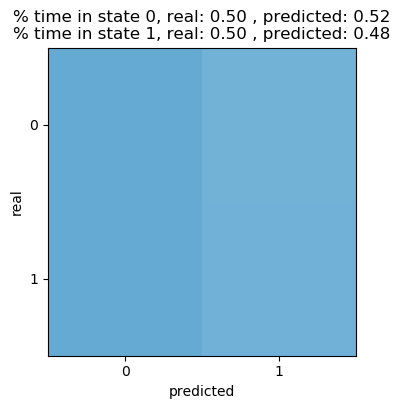

In [101]:
"""How well did it guess the states?"""
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# hmm.permute(find_permutation(state, this_hmm.most_likely_states(np.array([[o] for o in obs]), input=noisyinpt)))
state_pred = this_hmm.most_likely_states(np.array([[o] for o in obs]), input=noisyinpt)

conf = confusion_matrix(state, state_pred)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs.set_ylabel("real")
axs.set_xlabel("predicted")
axs.set_xticks([0,1])
axs.set_yticks([0,1])
axs.set_title('% time in state 0, real: ' + "%.2f" % (np.sum(state == 0)/len(state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 0)/len(state_pred)) +
              '\n% time in state 1, real: ' + "%.2f" % (np.sum(state == 1)/len(state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 1)/len(state_pred)))

In [98]:
"""Based on the inputs, what does it think the angles should be?"""
pred_latents, pred_angles = this_hmm.sample(len(obs), input=noisyinpt)

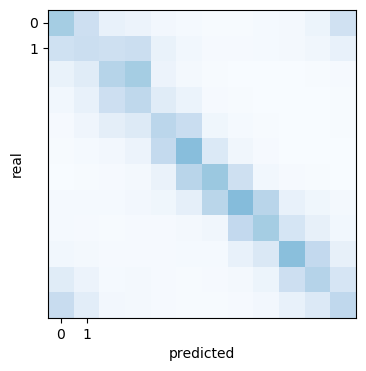

In [102]:
conf = confusion_matrix(obs, pred_angles)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs.set_ylabel("real")
axs.set_xlabel("predicted")
axs.set_xticks([0,1])
axs.set_yticks([0,1])